<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/07_Evaluation_%26_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Imports

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

Step 2 — Set the results directory

In [7]:
results_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results"

print("Results directory exists:", os.path.exists(results_dir))
print("Results directory:", results_dir)

Results directory exists: True
Results directory: /content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results


Step 3 - Define the result files

In [8]:
result_files = {
    "EfficientNetB0": "efficientnetb0_results.json",
    "ConvNeXt-Tiny": "convnext_tiny_results.json",
    "ResNet50": "resnet50_results.json"
}

for model_name, filename in result_files.items():
    file_path = os.path.join(results_dir, filename)

    print(
        f"{model_name:20} | "
        f"Exists: {os.path.exists(file_path)}"
    )

EfficientNetB0       | Exists: True
ConvNeXt-Tiny        | Exists: True
ResNet50             | Exists: True


Step 4 - Load the saved results

In [9]:
def load_results(filename):
    file_path = os.path.join(results_dir, filename)

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Result file not found: {file_path}"
        )

    with open(file_path, "r") as file:
        return json.load(file)


results = {}

for model_name, filename in result_files.items():
    results[model_name] = load_results(filename)

print("All model results loaded successfully.")

All model results loaded successfully.


Step 5 - Verify the loaded models

In [10]:
for model_name, result in results.items():
    print(
        f"{model_name}: "
        f"{result['test_accuracy']:.4%} test accuracy"
    )

EfficientNetB0: 91.5289% test accuracy
ConvNeXt-Tiny: 92.7686% test accuracy
ResNet50: 90.4959% test accuracy


Step 6 — Overall model comparison

In [11]:
comparison_data = []

for model_name, result in results.items():

    comparison_data.append({
        "Model": model_name,
        "Test Accuracy": result["test_accuracy"],
        "Test Loss": result["test_loss"],
        "Correct": result["correct_predictions"],
        "Incorrect": result["incorrect_predictions"],
        "Total Parameters": result["total_parameters"],
        "Trainable Parameters": result["trainable_parameters"],
        "Best Epoch": result["best_epoch"],
        "Best Validation Loss": result["best_val_loss"],
        "Epochs Completed": result["epochs_completed"]
    })


comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Test Accuracy,Test Loss,Correct,Incorrect,Total Parameters,Trainable Parameters,Best Epoch,Best Validation Loss,Epochs Completed
0,EfficientNetB0,0.915289,0.245581,443,41,4055976,6405,11,0.264638,14
1,ConvNeXt-Tiny,0.927686,0.212064,449,35,27823973,3845,14,0.222247,15
2,ResNet50,0.904959,0.272767,438,46,23597957,10245,6,0.301095,9


Step 7 — Test accuracy comparison

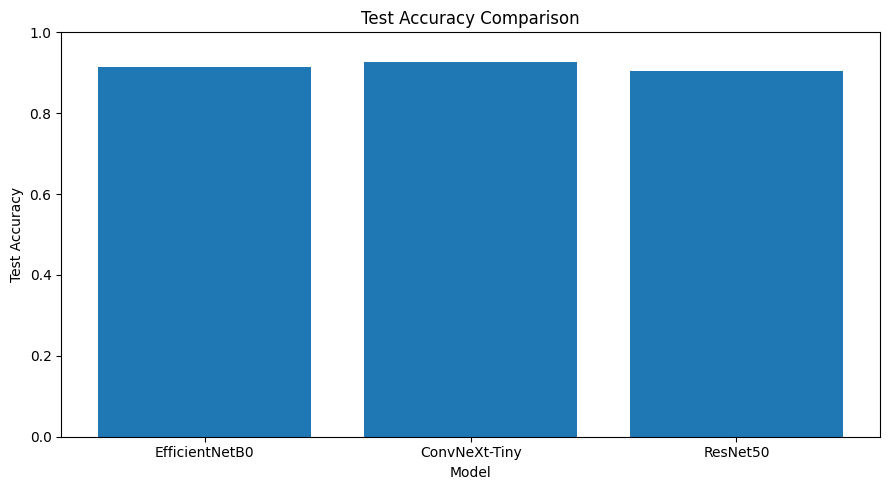

In [12]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Step 8 - Test loss comparison

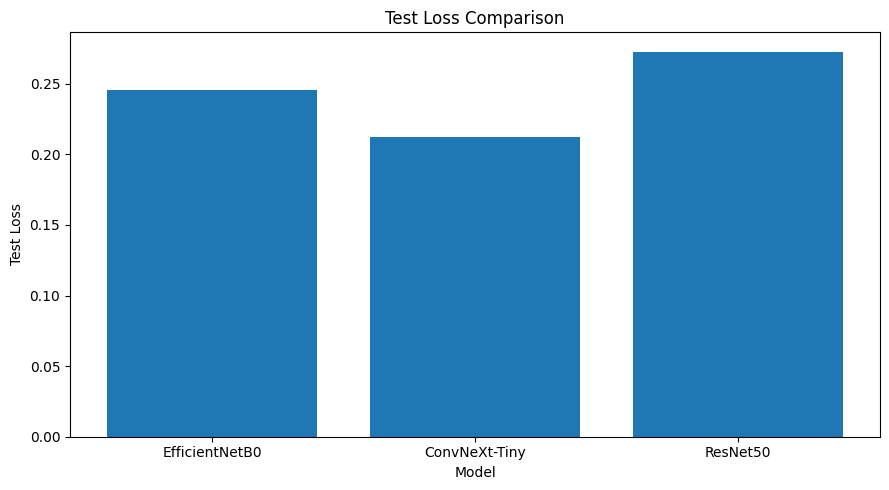

In [13]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Test Loss"]
)

plt.ylabel("Test Loss")
plt.xlabel("Model")
plt.title("Test Loss Comparison")

plt.tight_layout()
plt.show()

Step 9 - Correct and incorrect predictions

In [14]:
prediction_data = comparison_df[
    ["Model", "Correct", "Incorrect"]
]

prediction_data

,Model,Correct,Incorrect
0,EfficientNetB0,443,41
1,ConvNeXt-Tiny,449,35
2,ResNet50,438,46


Step 10 - Parameter comparison

In [15]:
parameter_data = comparison_df[
    [
        "Model",
        "Total Parameters",
        "Trainable Parameters",
        "Epochs Completed"
    ]
]

parameter_data

,Model,Total Parameters,Trainable Parameters,Epochs Completed
0,EfficientNetB0,4055976,6405,14
1,ConvNeXt-Tiny,27823973,3845,15
2,ResNet50,23597957,10245,9


Step 11 - Total parameter chart

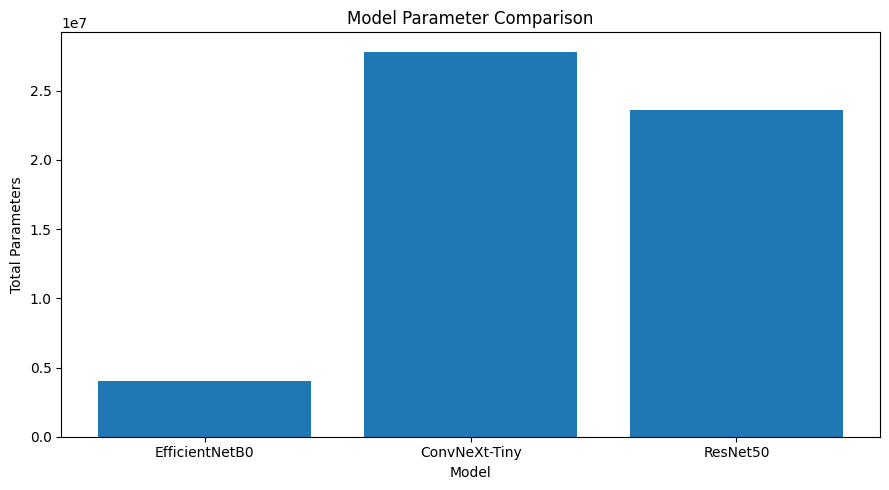

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Total Parameters"]
)

plt.ylabel("Total Parameters")
plt.xlabel("Model")
plt.title("Model Parameter Comparison")

plt.tight_layout()
plt.show()

Step 12 - Best validation loss and best epoch

In [17]:
validation_data = comparison_df[
    [
        "Model",
        "Best Epoch",
        "Best Validation Loss",
        "Epochs Completed"
    ]
]

validation_data

,Model,Best Epoch,Best Validation Loss,Epochs Completed
0,EfficientNetB0,11,0.264638,14
1,ConvNeXt-Tiny,14,0.222247,15
2,ResNet50,6,0.301095,9


Step 13 - Class-wise metrics

In [18]:
class_metrics = []

for model_name, result in results.items():

    report = result["classification_report"]

    for class_name in result["classes"]:

        class_metrics.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })


class_metrics_df = pd.DataFrame(class_metrics)

class_metrics_df

,Model,Class,Precision,Recall,F1-score,Support
0,EfficientNetB0,kitchen,0.981132,0.936937,0.958525,111
1,EfficientNetB0,bedroom,0.857143,0.840000,0.848485,100
2,EfficientNetB0,bar,0.977778,0.967033,0.972376,91
3,EfficientNetB0,livingroom,0.798246,0.858491,0.827273,106
4,EfficientNetB0,warehouse,1.000000,1.000000,1.000000,76
5,ConvNeXt-Tiny,kitchen,0.990566,0.945946,0.967742,111
6,ConvNeXt-Tiny,bedroom,0.881188,0.890000,0.885572,100
7,ConvNeXt-Tiny,bar,0.945652,0.956044,0.950820,91
8,ConvNeXt-Tiny,livingroom,0.853211,0.877358,0.865116,106
9,ConvNeXt-Tiny,warehouse,0.986842,0.986842,0.986842,76


Step 14 - Class-wise F1 comparison

In [19]:
f1_table = class_metrics_df.pivot(
    index="Class",
    columns="Model",
    values="F1-score"
)

f1_table

Model,ConvNeXt-Tiny,EfficientNetB0,ResNet50
Class,,,
bar,0.950820,0.972376,0.961326
bedroom,0.885572,0.848485,0.854369
kitchen,0.967742,0.958525,0.930233
livingroom,0.865116,0.827273,0.826291
warehouse,0.986842,1.000000,0.980392


Step 15 - Class-wise Precision comparison

In [20]:
precision_table = class_metrics_df.pivot(
    index="Class",
    columns="Model",
    values="Precision"
)

precision_table

Model,ConvNeXt-Tiny,EfficientNetB0,ResNet50
Class,,,
bar,0.945652,0.977778,0.966667
bedroom,0.881188,0.857143,0.830189
kitchen,0.990566,0.981132,0.961538
livingroom,0.853211,0.798246,0.822430
warehouse,0.986842,1.000000,0.974026


Step 16 - Class-wise Recall comparison

In [21]:
recall_table = class_metrics_df.pivot(
    index="Class",
    columns="Model",
    values="Recall"
)

recall_table

Model,ConvNeXt-Tiny,EfficientNetB0,ResNet50
Class,,,
bar,0.956044,0.967033,0.956044
bedroom,0.890000,0.840000,0.880000
kitchen,0.945946,0.936937,0.900901
livingroom,0.877358,0.858491,0.830189
warehouse,0.986842,1.000000,0.986842


Step 17 - Class-wise F1-score chart

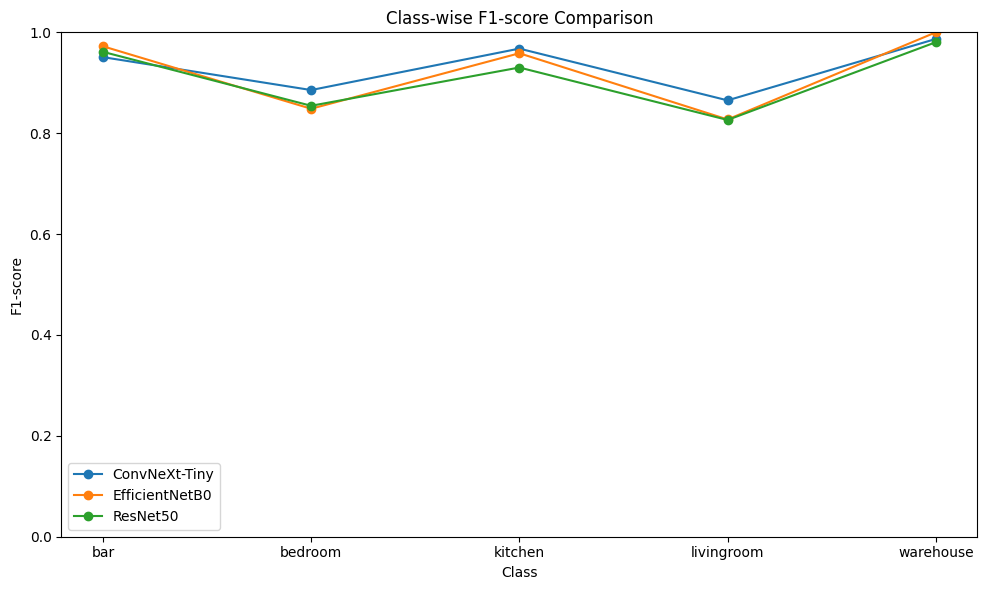

In [22]:
plt.figure(figsize=(10, 6))

for model_name in f1_table.columns:

    plt.plot(
        f1_table.index,
        f1_table[model_name],
        marker="o",
        label=model_name
    )

plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("Class-wise F1-score Comparison")
plt.legend()

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Step 18 - Confusion matrices

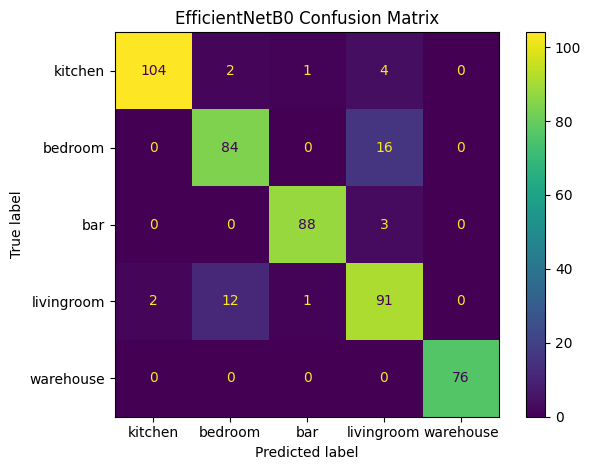

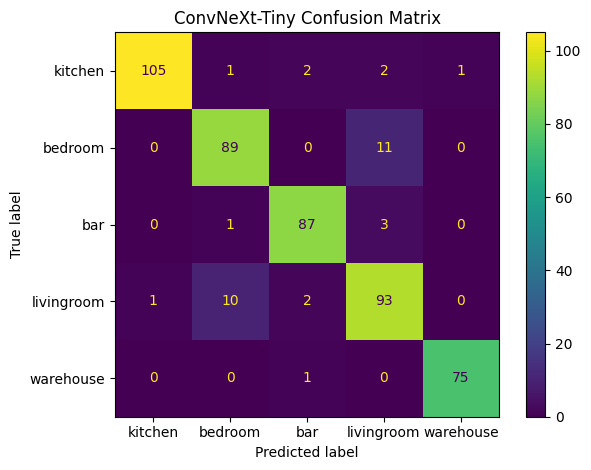

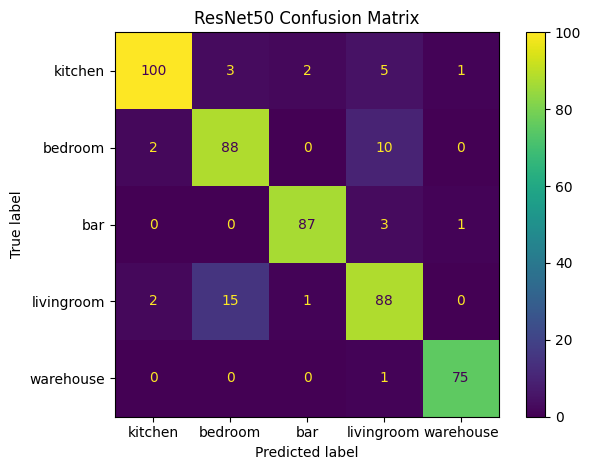

In [23]:
for model_name, result in results.items():

    cm = np.array(
        result["confusion_matrix"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=result["classes"]
    )

    disp.plot()

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

Step 19 - Learning curves

Accuracy curves

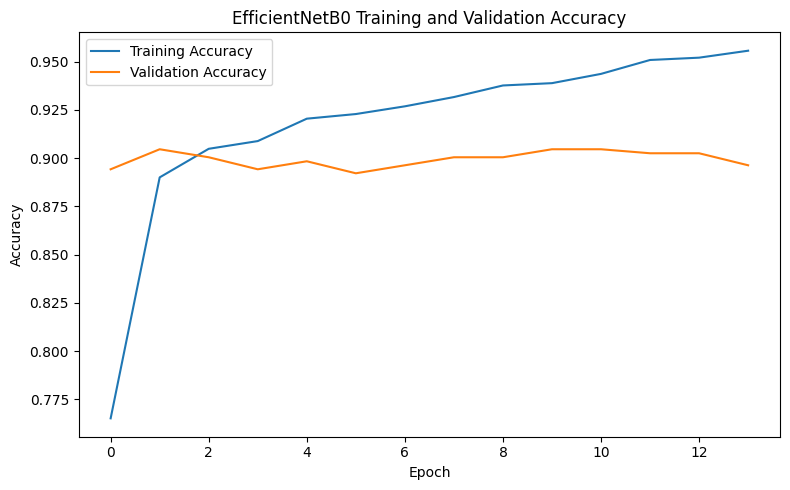

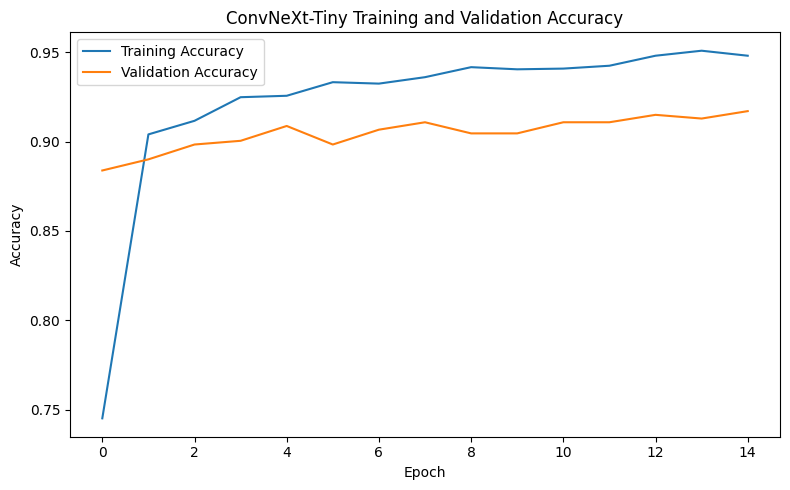

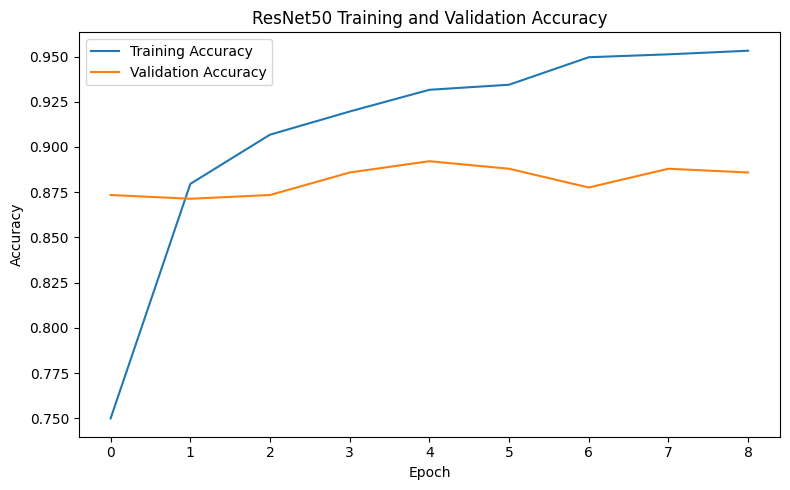

In [24]:
for model_name, result in results.items():

    history = result["history"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{model_name} Training and Validation Accuracy"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

Loss curves

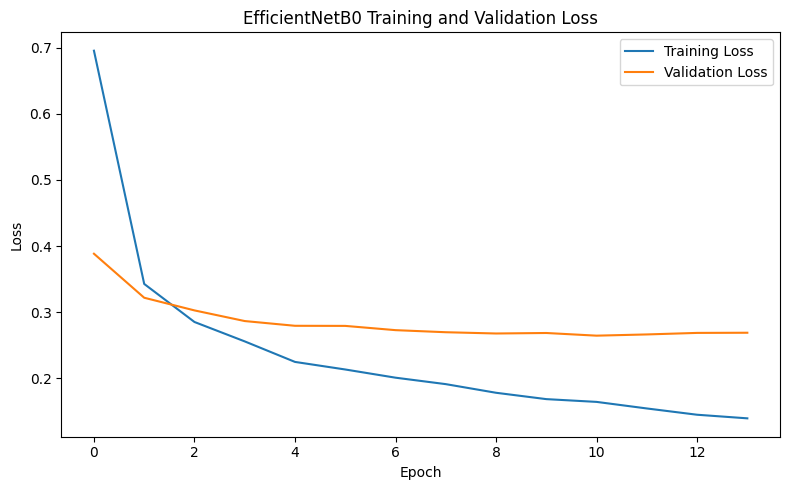

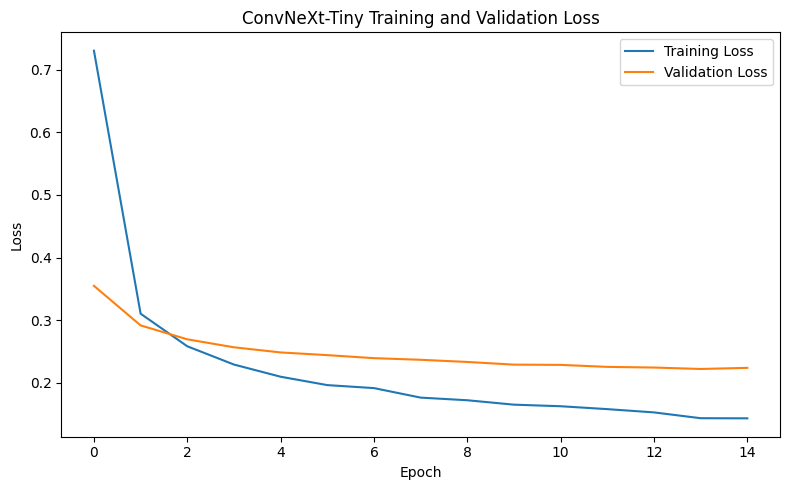

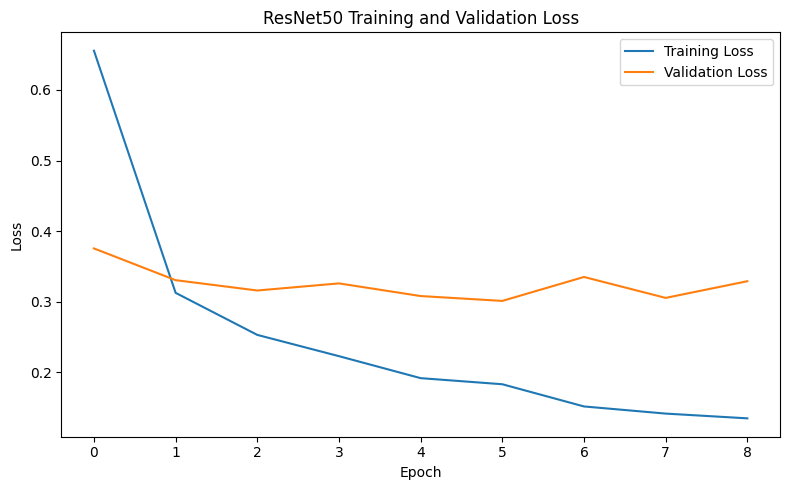

In [25]:
for model_name, result in results.items():

    history = result["history"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_name} Training and Validation Loss"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

Step 20 - Direct comparison of validation loss

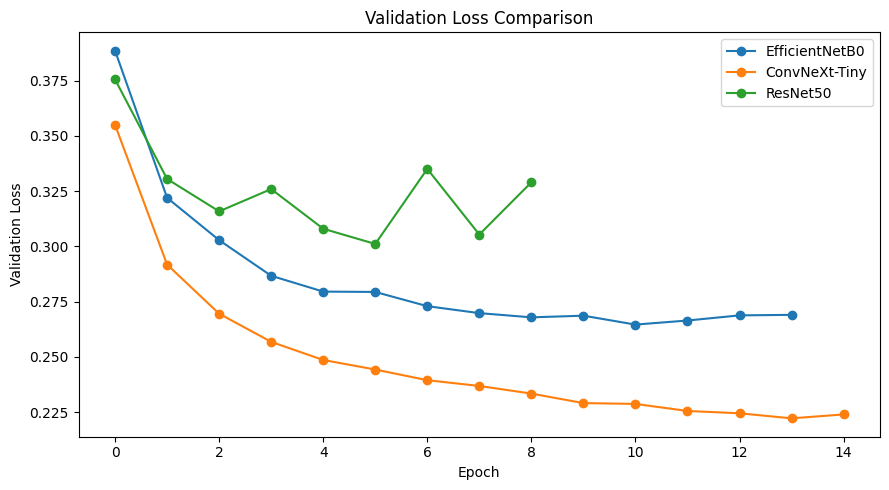

In [26]:
plt.figure(figsize=(9, 5))

for model_name, result in results.items():

    plt.plot(
        result["history"]["val_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()

plt.tight_layout()
plt.show()

Step 21 - Direct comparison of validation accuracy

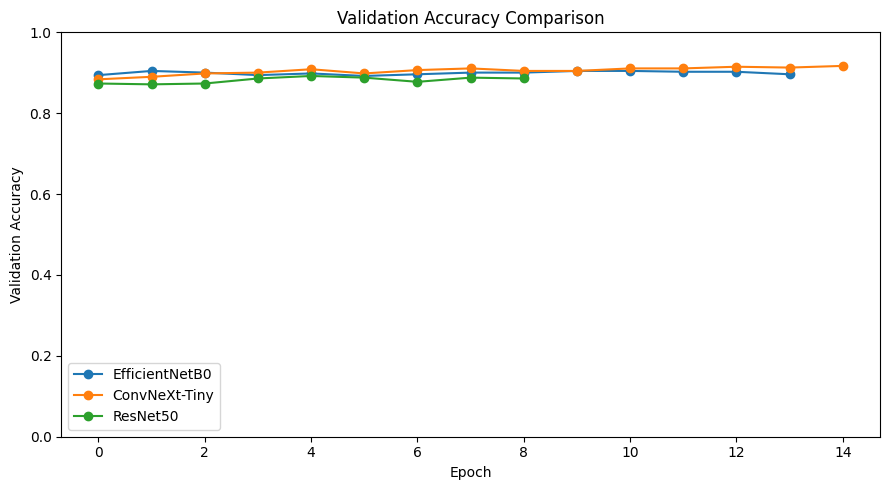

In [27]:
plt.figure(figsize=(9, 5))

for model_name, result in results.items():

    plt.plot(
        result["history"]["val_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

plt.legend()

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Step 22 - Check for the difficult classes

In [28]:
class_average_f1 = (
    class_metrics_df
    .groupby("Class")["F1-score"]
    .mean()
    .sort_values()
)

print("Average F1-score across the three models:")
print(class_average_f1)

Average F1-score across the three models:
Class
livingroom    0.839560
bedroom       0.862809
kitchen       0.952167
bar           0.961507
warehouse     0.989078
Name: F1-score, dtype: float64


Step 23 - Average model metrics

In [29]:
average_metrics = class_metrics_df.groupby(
    "Model"
)[
    ["Precision", "Recall", "F1-score"]
].mean()

average_metrics

,Precision,Recall,F1-score
Model,,,
ConvNeXt-Tiny,0.931492,0.931238,0.931218
EfficientNetB0,0.922860,0.920492,0.921332
ResNet50,0.910970,0.910795,0.910522


Step 24 - Verify that all models use the same classes

In [30]:
reference_classes = results["EfficientNetB0"]["classes"]

for model_name, result in results.items():

    if result["classes"] != reference_classes:
        print(
            f"WARNING: Class order differs for {model_name}"
        )
    else:
        print(
            f"{model_name}: Class order matches."
        )

EfficientNetB0: Class order matches.
ConvNeXt-Tiny: Class order matches.
ResNet50: Class order matches.


Step 25 - Final experiment summary

In [31]:
print("FINAL EXPERIMENT SUMMARY")
print("========================")

for model_name, result in results.items():

    print(f"\n{model_name}")
    print(f"Test Accuracy: {result['test_accuracy']:.4%}")
    print(f"Test Loss: {result['test_loss']:.4f}")
    print(f"Correct: {result['correct_predictions']}")
    print(f"Incorrect: {result['incorrect_predictions']}")
    print(f"Best Epoch: {result['best_epoch']}")
    print(f"Best Validation Loss: {result['best_val_loss']:.4f}")
    print(f"Total Parameters: {result['total_parameters']:,}")
    print(
        f"Trainable Parameters: "
        f"{result['trainable_parameters']:,}"
    )

FINAL EXPERIMENT SUMMARY

EfficientNetB0
Test Accuracy: 91.5289%
Test Loss: 0.2456
Correct: 443
Incorrect: 41
Best Epoch: 11
Best Validation Loss: 0.2646
Total Parameters: 4,055,976
Trainable Parameters: 6,405

ConvNeXt-Tiny
Test Accuracy: 92.7686%
Test Loss: 0.2121
Correct: 449
Incorrect: 35
Best Epoch: 14
Best Validation Loss: 0.2222
Total Parameters: 27,823,973
Trainable Parameters: 3,845

ResNet50
Test Accuracy: 90.4959%
Test Loss: 0.2728
Correct: 438
Incorrect: 46
Best Epoch: 6
Best Validation Loss: 0.3011
Total Parameters: 23,597,957
Trainable Parameters: 10,245


Step 8 — Final comparison statement